
===== FULL ABLATION TABLE =====
               model  horizon_h season  n_features  train_rmse  rmse   mae  baseline_rmse  improvement_pct
          full_model          1 Winter          32       0.608 0.679 0.483          0.786             13.6
          full_model          1 Summer          32       0.604 0.701 0.424          0.960             27.0
          full_model          3 Winter          32       1.424 1.685 1.305          1.879             10.3
          full_model          3 Summer          32       1.454 1.319 0.954          2.367             44.3
          full_model          6 Winter          32       2.211 2.748 2.157          3.127             12.1
          full_model          6 Summer          32       2.287 1.804 1.357          4.089             55.9
          full_model         12 Winter          32       2.925 3.807 3.043          4.754             19.9
          full_model         12 Summer          32       3.051 2.255 1.727          5.700             60.4
    

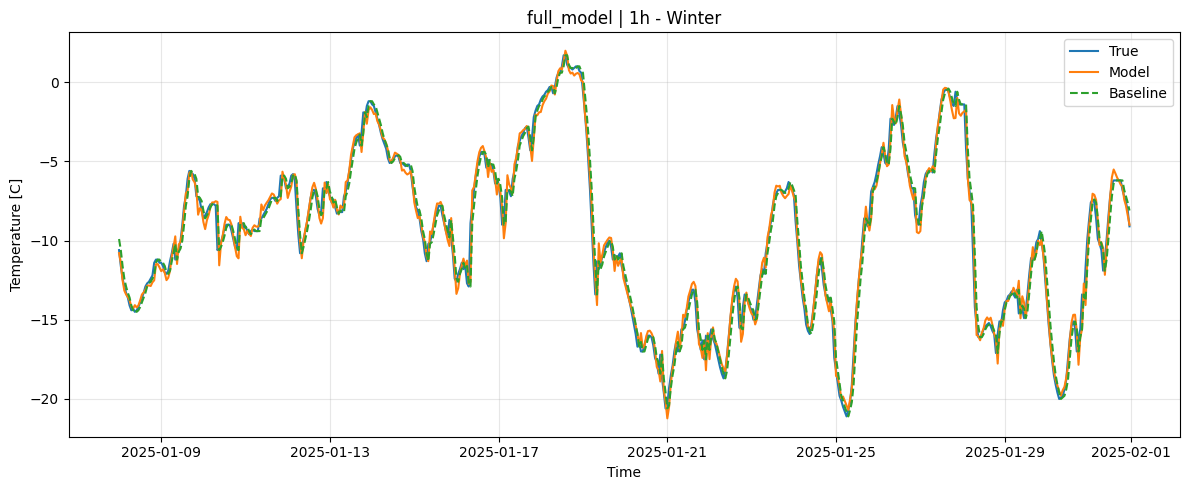

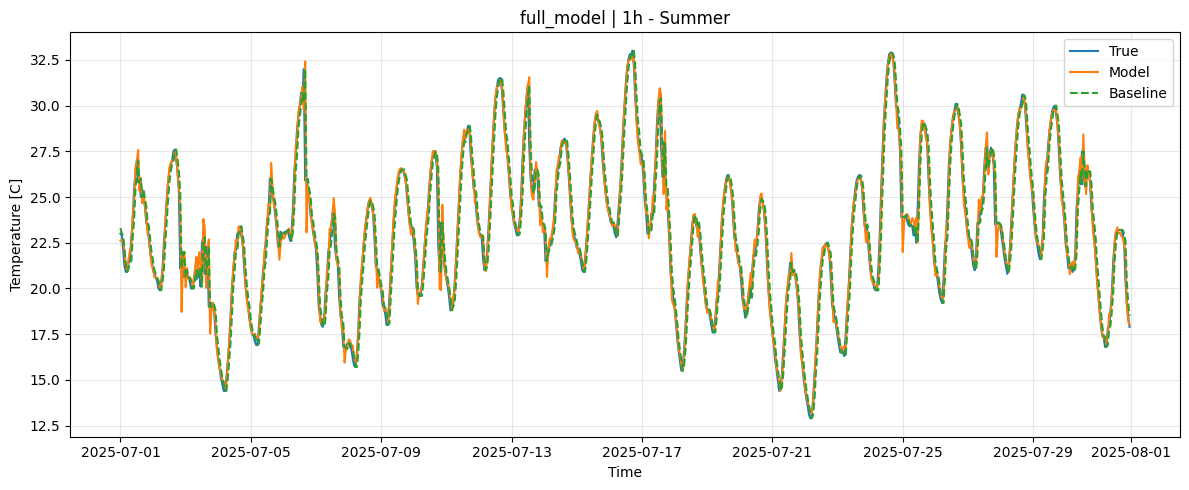

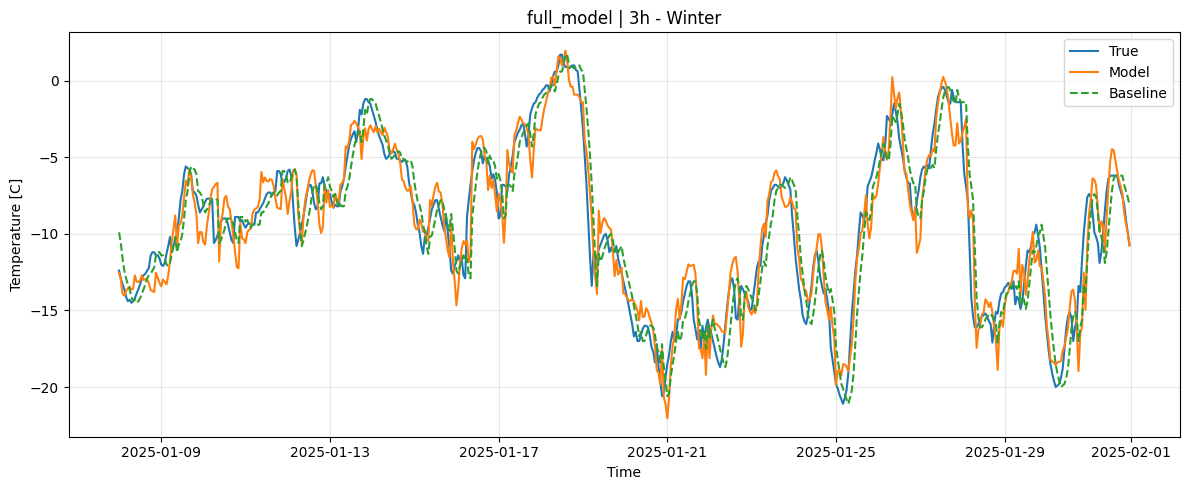

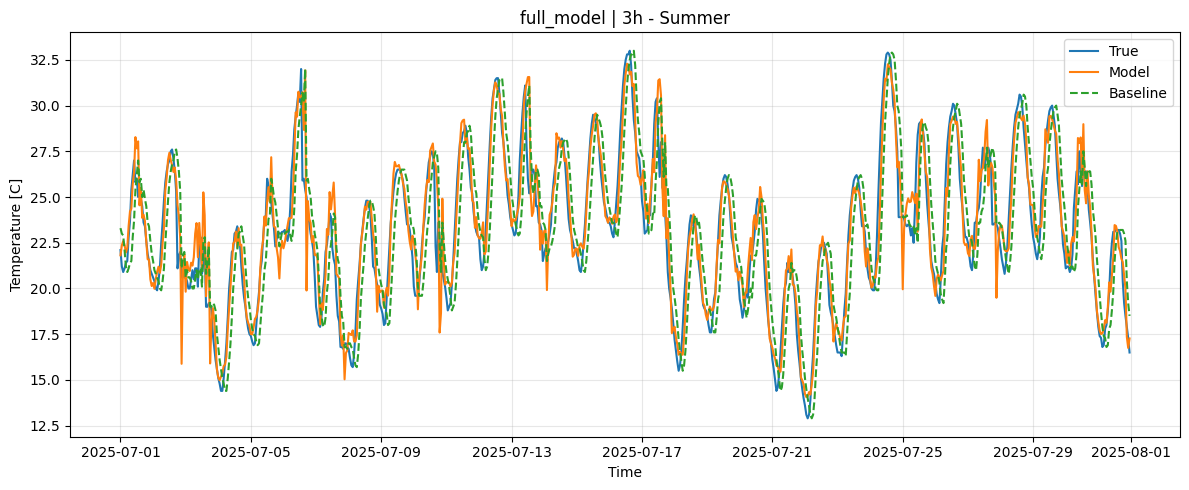

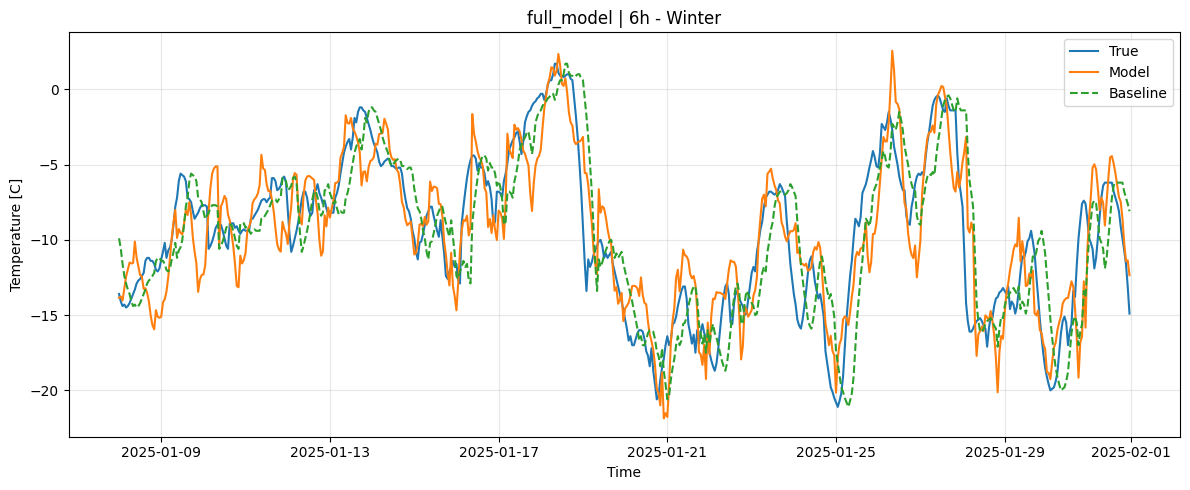

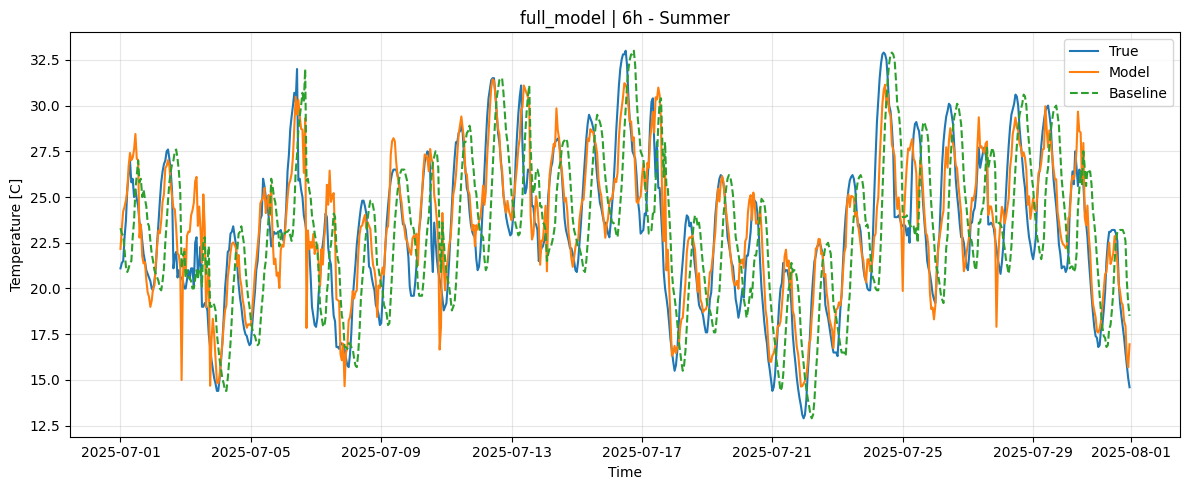

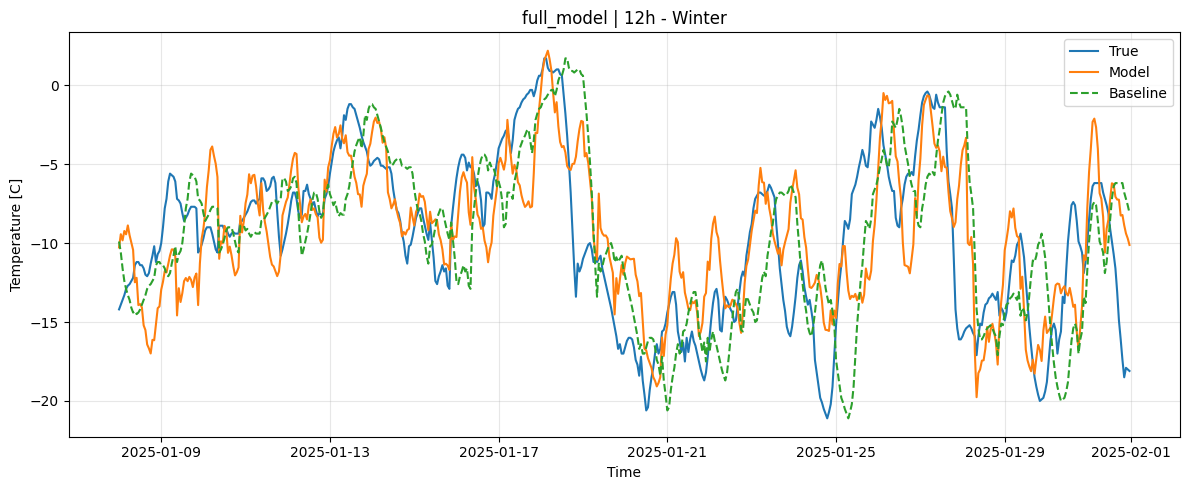

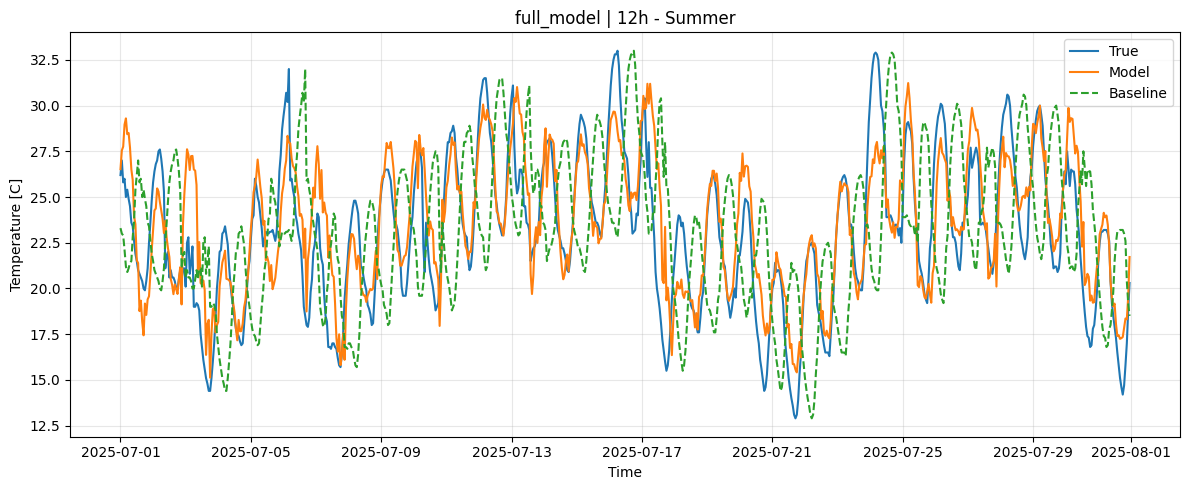

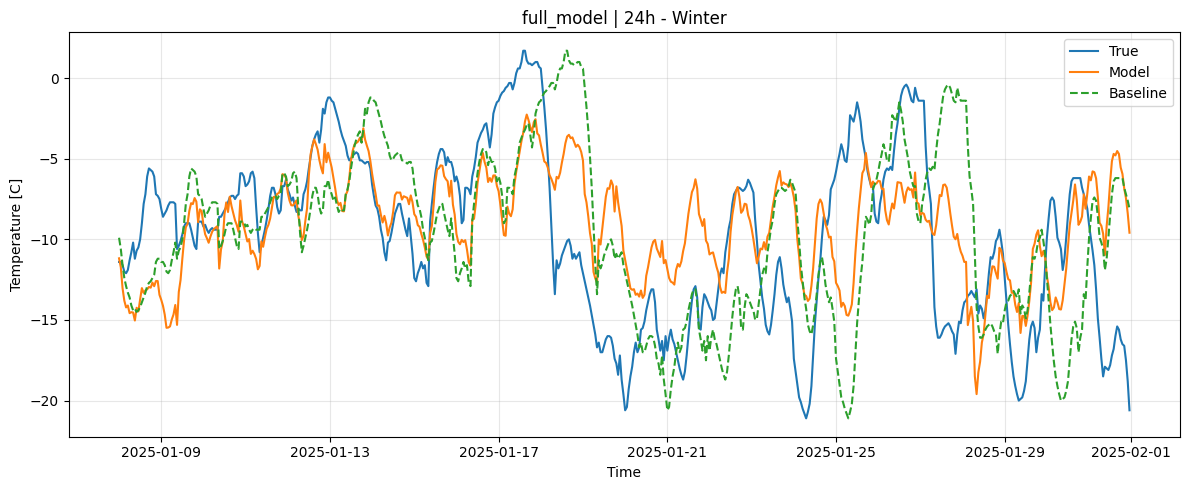

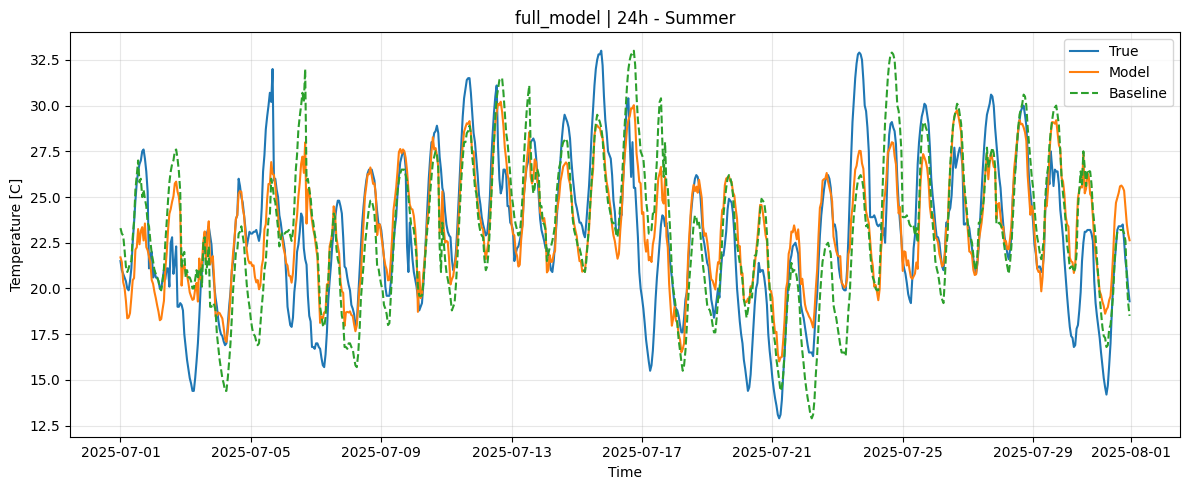

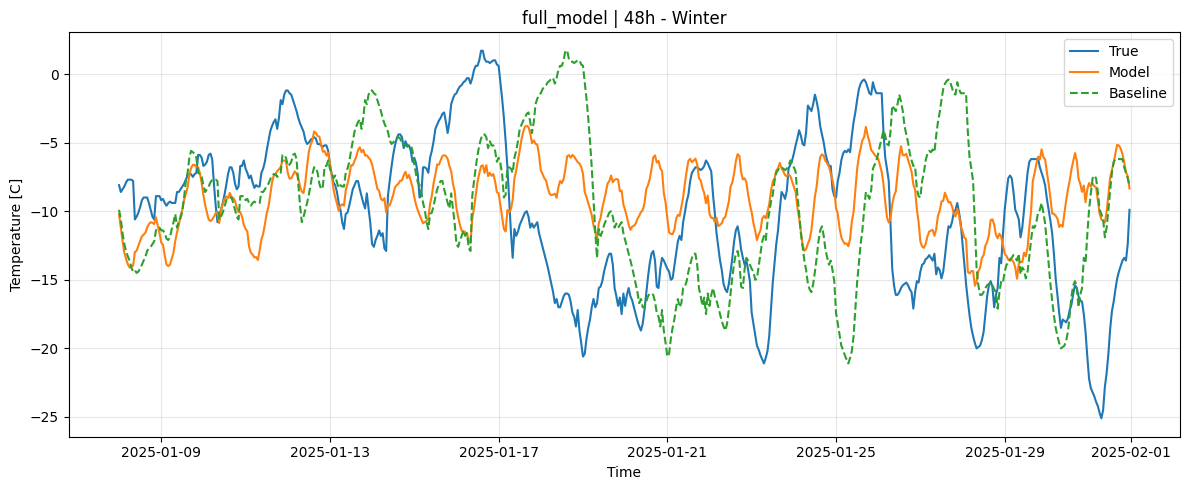

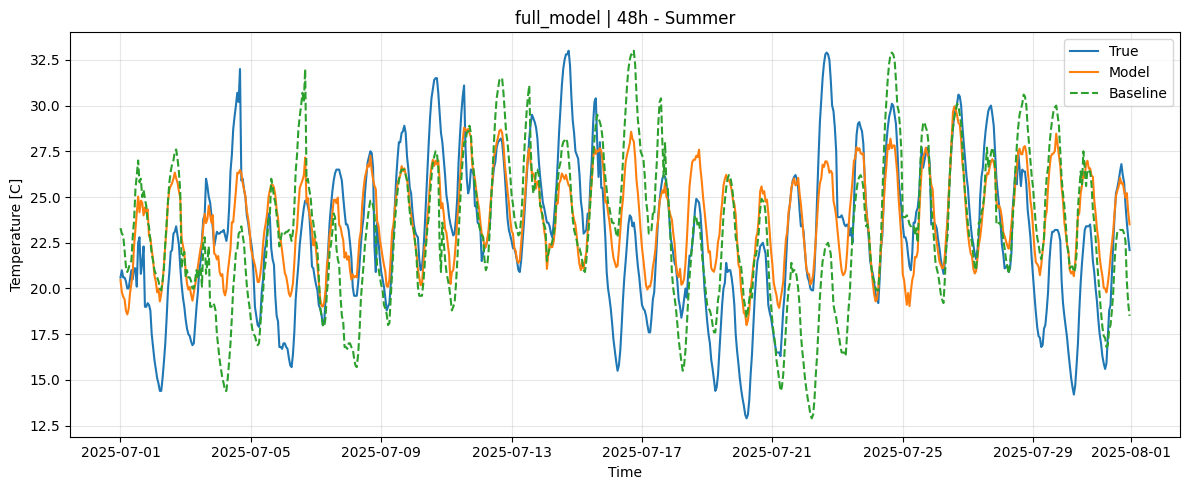

In [1]:
# ================================
# MECH 309 - Part 1
# Full variable redundancy / ablation study
# ================================

!pip -q install numpy pandas matplotlib requests

import math
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt


# -------------------------------
# Location
# -------------------------------
class Location:
    def __init__(self, name, lat, lon, timezone):
        self.name = name
        self.lat = lat
        self.lon = lon
        self.timezone = timezone

MONTREAL = Location("Montreal, QC", 45.5017, -73.5673, "America/Montreal")


# -------------------------------
# Fetch data
# -------------------------------
def fetch_open_meteo_hourly(start_date, end_date, location):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": location.lat,
        "longitude": location.lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,cloud_cover",
        "timezone": location.timezone,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    hourly = data["hourly"]
    idx = pd.to_datetime(hourly["time"])

    df = pd.DataFrame(index=idx)
    df["T"] = hourly["temperature_2m"]
    df["W"] = hourly["wind_speed_10m"]
    df["RH"] = hourly["relative_humidity_2m"]
    df["P"] = hourly["surface_pressure"]
    df["Cloud"] = hourly["cloud_cover"]

    return df


# -------------------------------
# Preprocess
# -------------------------------
def preprocess(df):
    df = df.sort_index()
    df = df[~df.index.duplicated()]

    full_idx = pd.date_range(df.index.min(), df.index.max(), freq="h")
    df = df.reindex(full_idx)

    df = df.interpolate().ffill().bfill()

    # Daily cycle
    hour = df.index.hour
    df["sin_day"] = np.sin(2 * np.pi * hour / 24)
    df["cos_day"] = np.cos(2 * np.pi * hour / 24)

    # Annual cycle
    doy = df.index.dayofyear
    df["sin_year"] = np.sin(2 * np.pi * doy / 365.25)
    df["cos_year"] = np.cos(2 * np.pi * doy / 365.25)

    return df


# -------------------------------
# Add lag features
# -------------------------------
def add_lags(df, col, lags):
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)
    return df


# -------------------------------
# Metrics
# -------------------------------
def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat) ** 2))

def mae(y, yhat):
    return np.mean(np.abs(y - yhat))


# -------------------------------
# Seasonal split
# -------------------------------
def seasonal_split(df, year, month):
    mask = (df.index.year == year) & (df.index.month == month)
    train_df = df.loc[~mask].copy()
    val_df = df.loc[mask].copy()
    return train_df, val_df


# -------------------------------
# Run one model
# -------------------------------
def run_model(df_base, features, h, year, month):
    df2 = df_base.copy()
    df2["target"] = df2["T"].shift(-h)
    df2 = df2.dropna()

    train_df, val_df = seasonal_split(df2, year, month)

    X_train = train_df[features].values
    y_train = train_df["target"].values

    X_val = val_df[features].values
    y_val = val_df["target"].values

    X_train = np.column_stack([np.ones(len(X_train)), X_train])
    X_val = np.column_stack([np.ones(len(X_val)), X_val])

    theta = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

    yhat_train = X_train @ theta
    yhat_val = X_val @ theta
    baseline = val_df["T"].values

    return {
        "train_rmse": rmse(y_train, yhat_train),
        "val_rmse": rmse(y_val, yhat_val),
        "val_mae": mae(y_val, yhat_val),
        "baseline_rmse": rmse(y_val, baseline),
        "baseline_mae": mae(y_val, baseline),
        "val_index": val_df.index,
        "y_val": y_val,
        "yhat_val": yhat_val,
        "baseline": baseline,
    }


# ================================
# MAIN
# ================================

# 1) Load and preprocess one year of data
df = fetch_open_meteo_hourly("2025-01-01", "2025-12-31", MONTREAL)
df = preprocess(df)

# 2) Add lagged variables
df = add_lags(df, "T", [1, 2, 3, 6, 12, 24, 48, 72, 168])
df = add_lags(df, "W", [1, 6, 12, 24, 48])
df = add_lags(df, "RH", [1, 6, 24])
df = add_lags(df, "P", [1, 6, 24])
df = add_lags(df, "Cloud", [1, 6, 24])

# 3) Define feature groups
feature_groups = {
    "temperature_core": [
        "T",
        "T_lag1", "T_lag2", "T_lag3", "T_lag6", "T_lag12",
        "T_lag24", "T_lag48", "T_lag72", "T_lag168"
    ],
    "wind": [
        "W",
        "W_lag1", "W_lag6", "W_lag12", "W_lag24", "W_lag48"
    ],
    "humidity": [
        "RH",
        "RH_lag1", "RH_lag6", "RH_lag24"
    ],
    "pressure": [
        "P",
        "P_lag1", "P_lag6", "P_lag24"
    ],
    "cloud": [
        "Cloud",
        "Cloud_lag1", "Cloud_lag6", "Cloud_lag24"
    ],
    "daily_cycle": [
        "sin_day", "cos_day"
    ],
    "seasonal_cycle": [
        "sin_year", "cos_year"
    ]
}

# Full model = all groups
full_features = []
for group in feature_groups.values():
    full_features += group

# 4) Build ablation models
feature_sets = {
    "full_model": full_features,
    "temperature_only": feature_groups["temperature_core"],
    "no_wind": [f for f in full_features if f not in feature_groups["wind"]],
    "no_humidity": [f for f in full_features if f not in feature_groups["humidity"]],
    "no_pressure": [f for f in full_features if f not in feature_groups["pressure"]],
    "no_cloud": [f for f in full_features if f not in feature_groups["cloud"]],
    "no_daily_cycle": [f for f in full_features if f not in feature_groups["daily_cycle"]],
    "no_seasonal_cycle": [f for f in full_features if f not in feature_groups["seasonal_cycle"]],
    "no_wind_no_pressure": [f for f in full_features if f not in feature_groups["wind"] + feature_groups["pressure"]],
    "no_humidity_no_cloud": [f for f in full_features if f not in feature_groups["humidity"] + feature_groups["cloud"]],
}

# 5) Forecast horizons and validation months
horizons = [1, 3, 6, 12, 24, 48]
months = [
    (2025, 1, "Winter"),
    (2025, 7, "Summer")
]

# 6) Run all comparisons
rows = []
stored_results = {}

for model_name, feats in feature_sets.items():
    stored_results[model_name] = []

    for h in horizons:
        for year, month, season in months:
            res = run_model(df, feats, h, year, month)

            improvement = 100 * (res["baseline_rmse"] - res["val_rmse"]) / res["baseline_rmse"]

            rows.append({
                "model": model_name,
                "horizon_h": h,
                "season": season,
                "n_features": len(feats),
                "train_rmse": round(res["train_rmse"], 3),
                "rmse": round(res["val_rmse"], 3),
                "mae": round(res["val_mae"], 3),
                "baseline_rmse": round(res["baseline_rmse"], 3),
                "improvement_pct": round(improvement, 1)
            })

            stored_results[model_name].append({
                "h": h,
                "season": season,
                **res
            })

comparison_df = pd.DataFrame(rows)

# 7) Print full table
print("\n===== FULL ABLATION TABLE =====")
print(comparison_df.to_string(index=False))

# 8) Print best model for each horizon/season
print("\n===== BEST MODEL BY HORIZON / SEASON =====")
for h in horizons:
    for _, _, season in months:
        subset = comparison_df[
            (comparison_df["horizon_h"] == h) &
            (comparison_df["season"] == season)
        ].sort_values("rmse")
        best = subset.iloc[0]
        print(
            f"h={h}h | {season} | best={best['model']} | "
            f"RMSE={best['rmse']:.3f} | baseline={best['baseline_rmse']:.3f} | "
            f"improvement={best['improvement_pct']:.1f}%"
        )

# 9) Average RMSE by model across all cases
summary_df = comparison_df.groupby("model", as_index=False).agg({
    "rmse": "mean",
    "mae": "mean",
    "baseline_rmse": "mean",
    "improvement_pct": "mean",
    "n_features": "first"
}).sort_values("rmse")

print("\n===== AVERAGE PERFORMANCE ACROSS ALL HORIZONS / SEASONS =====")
print(summary_df.to_string(index=False))

# 10) Optional plotting of one chosen model
plot_model = "full_model"   # change this to another model if you want

for r in stored_results[plot_model]:
    plt.figure(figsize=(12, 5))
    plt.plot(r["val_index"], r["y_val"], label="True")
    plt.plot(r["val_index"], r["yhat_val"], label="Model")
    plt.plot(r["val_index"], r["baseline"], "--", label="Baseline")
    plt.title(f"{plot_model} | {r['h']}h - {r['season']}")
    plt.xlabel("Time")
    plt.ylabel("Temperature [C]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()